# Phase 1: Environment Setup & Data Ingestion
Before we build the forecasting engine, we import our machine learning libraries (specifically **LightGBM** for its highly optimized tree-based architecture) and load our fully engineered dataset. Crucially, we immediately convert the `datetime` column into the DataFrame's index. In time-series forecasting, locking the time index is mandatory to ensure the AI respects chronological order and physical reality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import lightgbm as lgb
import re
from sklearn.metrics import mean_absolute_percentage_error

plt.style.use('ggplot')

df_master_ml = pd.read_csv('./Dataset/Final_dataset.csv')

df_master_ml['datetime'] = pd.to_datetime(df_master_ml['datetime'])
df_master_ml = df_master_ml.set_index('datetime')

print(f"Dataset Shape: {df_master_ml.shape}")

Dataset Shape: (89101, 27)


In [2]:
df_master_ml.dtypes

generation_mw                      float64
demand_mw                          float64
load_shedding                      float64
hour                                 int64
day_of_week                          int64
month                                int64
year                                 int64
is_weekend                           int64
season                               int64
hour_sin                           float64
hour_cos                           float64
month_sin                          float64
month_cos                          float64
day_of_week_sin                    float64
day_of_week_cos                    float64
target_next_hour_demand            float64
lag_previous_hour                  float64
lag_yesterday_target_hour          float64
lag_lastweek_target_hour           float64
rolling_mean_6h                    float64
rolling_mean_24h                   float64
apparent_temperature               float64
precipitation_mm                   float64
cloud_cover

# Phase 2: Strategic Feature Selection (Decluttering the AI's Workspace)
Machine Learning algorithms are inherently greedy; if you feed them collinear (duplicate) data or categorical crutches, they become lazy and overfit. Through iterative testing, we discovered two features that add noise rather than value:
1. **`generation_mw`**: This is practically identical to `demand_mw` (minus load shedding). Giving the AI both creates heavy collinearity. We drop it to crown `demand_mw` as the undisputed baseline.
2. **`day_of_week`**: This raw categorical feature acts as a "shortcut." By explicitly deleting it, we take away the AI's crutch and *force* it to navigate the continuous, cyclical geometry of the week using our `day_of_week_sin` and `cos` waves, resulting in smoother, more accurate boundary transitions.

In [3]:
print("--- Phase 2: Strategic Feature Selection ---")

target = 'target_next_hour_demand'

excluded = [
    'generation_mw', 
    'day_of_week'    
]

features = [col for col in df_master_ml.columns if col != target and col not in excluded]

print(f"Target: {target}")
print(f"Total Features fed to the AI: {len(features)}")
print(f"Excluded Features: {excluded}")

--- Phase 2: Strategic Feature Selection ---
Target: target_next_hour_demand
Total Features fed to the AI: 24
Excluded Features: ['generation_mw', 'day_of_week', 'lag_previous_hour', 'lag_yesterday_target_hour', 'lag_lastweek_target_hour', 'precipitation_mm', 'cloud_cover_pct', 'year', 'is_weekend', 'manufacturing_constant_2015_usd', 'population_total']


# Phase 3: Chronological Splitting & LightGBM Sanitization
To properly evaluate a time-series model, we must prevent "time travel." We strictly split the data chronologically, allowing the AI to learn human behavior and grid physics from 2015 through the end of 2023. It will then take its "final exam" by attempting to predict the unseen future of 2024 and 2025. 

Additionally, we run a quick sanitizer to strip any special characters from the column names, which ensures LightGBM's internal C++ backend processes the data without throwing syntax errors.

In [4]:
print("--- Phase 3: Data Splitting & Sanitization ---")

df_master_ml = df_master_ml.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
for col in df_master_ml.columns:
    if df_master_ml[col].dtype == 'object' or df_master_ml[col].dtype.name == 'string':
        df_master_ml[col] = df_master_ml[col].astype('category')

train_end_date = pd.to_datetime('2023-12-31')
test_start_date = pd.to_datetime('2024-01-01')
test_end_date = pd.to_datetime('2025-06-17')

train_df = df_master_ml[df_master_ml.index <= train_end_date].copy()
test_df = df_master_ml[(df_master_ml.index >= test_start_date) & (df_master_ml.index <= test_end_date)].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print(f"Training Memory: {len(X_train)} hours (2015 - 2023)")
print(f"Testing  Memory: {len(X_test)} hours (2024 - 2025)")

--- Phase 3: Data Splitting & Sanitization ---
Training Memory: 76273 hours (2015 - 2023)
Testing  Memory: 12793 hours (2024 - 2025)


# Phase 4: Model Training & Results
We instantiate the `LGBMRegressor` using our hyperparameter-tuned architecture (limiting depth to prevent overfitting and tweaking the learning rate for stable gradient descent). 

To prove our AI is actually intelligent, we benchmark it against a "Naive Baseline." The Naive Baseline represents the simplest human assumption: *"Whatever the demand is right now, it will be exactly the same next hour."* We compare the Mean Absolute Percentage Error (MAPE) of both approaches to see how much intelligence the AI adds.

In [5]:
print("--- Phase 4: LightGBM Training & Evaluation ---\n")

model = lgb.LGBMRegressor(
    n_estimators=500,     
    learning_rate=0.05,   
    max_depth=8,          
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM... (Learning grid physics from 2015-2023)")
model.fit(X_train, y_train)

test_df['lgbm_prediction'] = model.predict(X_test)

test_df['baseline_prediction'] = test_df['demand_mw']

baseline_mape = mean_absolute_percentage_error(test_df[target], test_df['baseline_prediction']) * 100
lgbm_mape = mean_absolute_percentage_error(test_df[target], test_df['lgbm_prediction']) * 100

print("\n--- RESULTS ---")
print(f"Naive Baseline Error: {baseline_mape:.2f}%")
print(f"LightGBM Error:       {lgbm_mape:.2f}%")

--- Phase 4: LightGBM Training & Evaluation ---

Training LightGBM... (Learning grid physics from 2015-2023)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2430
[LightGBM] [Info] Number of data points in the train set: 76273, number of used features: 24
[LightGBM] [Info] Start training from score 8261.610894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

--- RESULTS ---
Naive Baseline Error: 3.33%
LightGBM Error:       1.75%


# Phase 5: Feature Importances
Finally, we reverse-engineer the AI's decision-making algorithm. By extracting the `feature_importances_` array, we can visualize exactly how many times the LightGBM trees split based on specific data columns. This confirms whether the model relies on logical physical constraints (like current demand and geometry of time) or if it is getting distracted by noise.

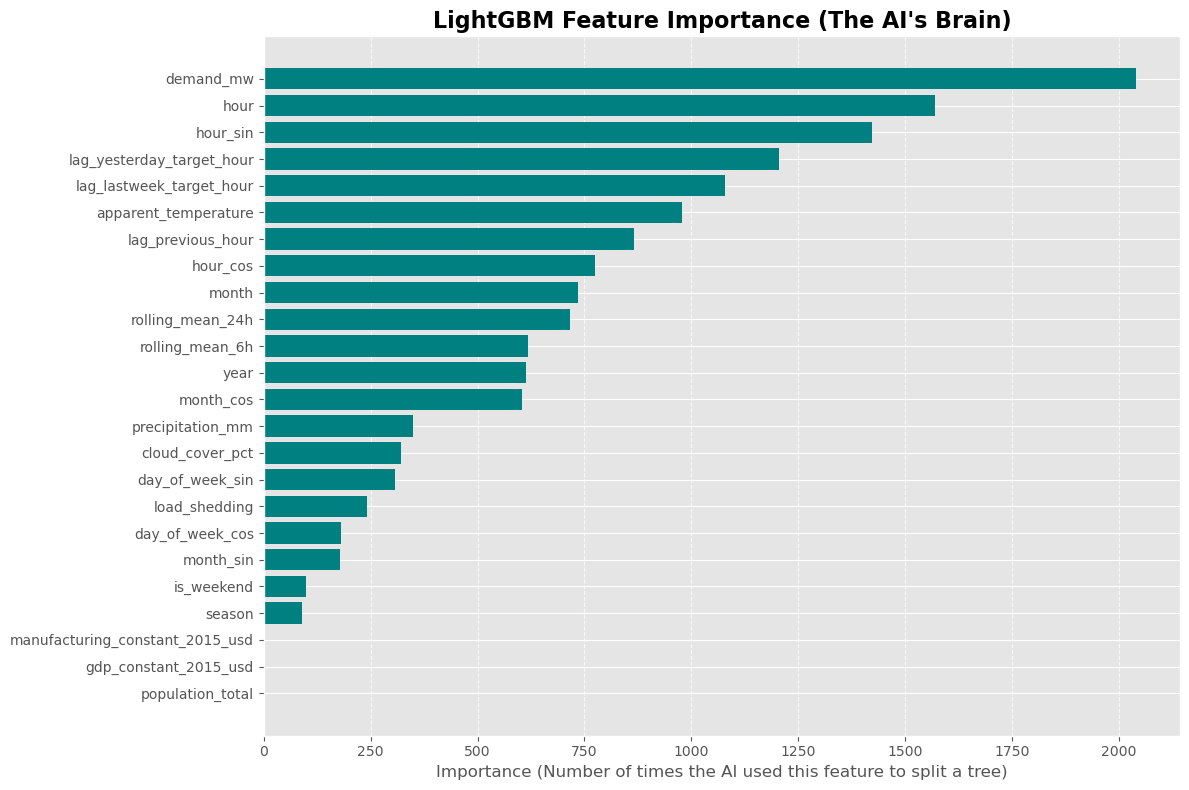

In [6]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True) 

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Importance (Number of times the AI used this feature to split a tree)', fontsize=12)
plt.title('LightGBM Feature Importance (The AI\'s Brain)', fontsize=16, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()